# Boiler Plate Code for All Projects


In [49]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
import operator
from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


## PDF Resume Loader


In [50]:
import pdfplumber
from pathlib import Path

def extract_text_from_pdf(pdf_path: str) -> str:
    """
    Extracts and returns all text from a PDF file.
    
    Args:
        pdf_path: Full path to the PDF file (e.g. 'C:/Users/you/resume.pdf')
    
    Returns:
        A single string containing all extracted text from the PDF.
    """
    full_text = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                full_text.append(text)

    return "\n".join(full_text)



## Set the LLM Object


In [51]:
llm =ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

## Pydantic Schemas for Resume Analysis

In [52]:
class Section(BaseModel):
    name: str = Field(description="Name of the resume section. E.g. 'Work Experience', 'Skills', 'Education', 'Projects', 'Summary'.")
    analysis_focus: str = Field(description="What specifically to evaluate in this section. E.g. 'Check if job descriptions have quantifiable achievements and strong action verbs'.")

class Sections(BaseModel):
    sections: List[Section] = Field(description="List of resume sections identified and to be analyzed.")

# Augmented LLM


In [53]:
# from urllib import response


planner = llm.with_structured_output(Sections)
# response = planner.invoke(resume_text)
# len(response.sections)

# Graph States


In [54]:
class State(TypedDict):
    pdf_path: str                                        # Input: path to the resume PDF
    resume_text: str                                     # Extracted text from the PDF
    sections: List[Section]                              # Resume sections identified by orchestrator
    completed_sections: Annotated[list, operator.add]    # Feedback from each worker
    final_report: str                                    # Final combined feedback report


class WorkerState(TypedDict):
    section: Section
    resume_text: str                                     # <-- add this line
    completed_sections: Annotated[list, operator.add]

# Nodes


## Orchestrator Node

In [55]:
def orchestrator(state: State) -> State:
    """Reads the resume text and plans which sections to analyze"""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert resume analyst. 
Your job is to read a resume and identify all the major sections present in it.
For each section, define a specific analysis focus — what should be evaluated in that section.

Common sections to look for: Summary/Objective, Work Experience, Education, Skills, Projects, Certifications, Achievements.
Only include sections that are actually present in the resume."""),
        ("human", "Here is the resume text:\n\n{resume_text}\n\nIdentify all sections present and what to analyze in each.")
    ])
    
    planner = llm.with_structured_output(Sections)
    chain = prompt | planner
    response = chain.invoke({"resume_text": state["resume_text"]})
    
    return {
        "sections": response.sections
    }

## Worker Node

In [56]:
def llm_call(state: WorkerState) -> WorkerState:
    """Analyzes a single resume section and returns detailed feedback"""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert resume reviewer with years of experience in hiring and career coaching.
You are analyzing a specific section of a candidate's resume.
Be specific, constructive, and actionable in your feedback.
Point out both strengths and areas for improvement.
If something is missing that should be there, call it out."""),
        ("human", """Section to analyze: {section_name}
        
What to focus on: {analysis_focus}

Resume content:
{resume_text}

Provide detailed feedback for this section only.""")
    ])
    
    chain = prompt | llm
    response = chain.invoke({
        "section_name": state["section"].name,
        "analysis_focus": state["section"].analysis_focus,
        "resume_text": state["resume_text"]
    })

    # ── Extract clean text from response ──────────────────────────────────
    if isinstance(response.content, list):
        text = " ".join([block["text"] for block in response.content if block.get("type") == "text"])
    else:
        text = response.content

    return {"completed_sections": [f"### {state['section'].name}\n\n{text}"]}

# Summarizer Node


In [57]:
def synthesizer(state: State) -> State:
    """Combines all section feedback into a final resume analysis report"""
    
    completed_sections = state["completed_sections"]
    sections_text = "\n\n---\n\n".join(completed_sections)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert resume coach finalizing a full resume review.
You will be given individual section feedbacks.
Your job is to:
1. Write a brief overall summary of the resume (3-4 sentences)
2. List the top 3 strengths of the resume
3. List the top 3 areas that need improvement
4. Then include all the detailed section feedbacks below"""),
        ("human", "Here are the individual section feedbacks:\n\n{sections_text}")
    ])
    
    chain = prompt | llm
    response = chain.invoke({"sections_text": sections_text})

    # ── Extract clean text from response ──────────────────────────────────
    if isinstance(response.content, list):
        summary = " ".join([block["text"] for block in response.content if block.get("type") == "text"])
    else:
        summary = response.content

    final_report = f"""# Resume Analysis Report

{summary}

---

## Detailed Section Feedback

{sections_text}
"""
    
    return {"final_report": final_report}

# Worker Assigner Send Method


In [58]:
def assign_workers(state: State):
    """Assigns a worker to each resume section identified by the orchestrator"""

    print(f"Orchestrator identified {len(state['sections'])} sections to analyze.")
    
    return [
        Send("llm_call", {
            "section": s,
            "resume_text": state["resume_text"]    # <-- pass resume_text to each worker
        }) 
        for s in state["sections"]
    ]

## Build and Run the Graph

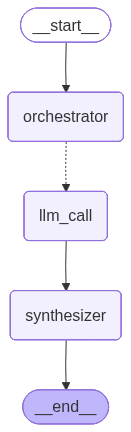

In [59]:
# ── Build Graph ───────────────────────────────────────────────────────────
orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

orchestrator_worker = orchestrator_worker_builder.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(orchestrator_worker.get_graph().draw_mermaid_png())




In [60]:
# ── Run ───────────────────────────────────────────────────────────────────
pdf_path = r"C:\Users\dhanu\Desktop\Resume\1CR22AI037_DHANUSH_RESUME_infosys.pdf"  # <-- Replace with your actual PDF path

resume_text = extract_text_from_pdf(pdf_path)

state = orchestrator_worker.invoke({
    "pdf_path": pdf_path,
    "resume_text": resume_text
})

print(state["final_report"])

Orchestrator identified 7 sections to analyze.
# Resume Analysis Report

This final review summarizes the strengths and critical refinements for your resume. You have a highly competitive profile for a 2026 graduate, particularly due to your ability to bridge the gap between traditional Full-Stack Engineering and modern AI/ML implementation.

### **Overall Summary**
Your resume presents a robust "AI-integrated Full Stack" identity, moving far beyond the standard projects seen at the entry level. You demonstrate sophisticated architectural choices—such as using Redis for performance and Pinecone for vector search—which signal a high level of engineering maturity. By addressing specific typos and ensuring your technical skills list fully reflects the advanced tools used in your projects, you will be positioned as a top-tier candidate for both specialized AI startups and major tech firms.

### **Top 3 Strengths**
1.  **Synergistic Technical Stack:** Unlike many students who keep AI and We